# Nexus Digital — Lead Pipeline Deep Dive
## Comprehensive Analysis of FY2024 Lead Data

**Context:** Nexus Digital doubled their marketing budget to $3.2M and expanded the sales team from 4 to 6 reps. Lead volume surged 60%, but win rate dropped from 14% to 8.3%. The CEO wants to know: *"Are we generating the wrong leads, or are we failing to convert the right ones?"*

This notebook answers all 10 analytical questions, defines KPIs, and provides actionable recommendations.

---

**Important note on `days_to_first_contact`:** Despite the column name, this field is measured in **hours**, not days.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# Style setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

NEXUS_COLORS = ['#2C73D2', '#0089BA', '#00BFA0', '#FF6F61', '#FFC75F', '#845EC2', '#D65DB1', '#FF9671']

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 0. Data Loading & Exploration

In [2]:
df = pd.read_csv('dataset.csv')

# Parse dates
df['created_date'] = pd.to_datetime(df['created_date'])
df['last_activity_date'] = pd.to_datetime(df['last_activity_date'])

# Replace string 'NULL' with actual NaN
df['lost_reason'] = df['lost_reason'].replace('NULL', np.nan)

# Derived columns
df['cycle_days'] = (df['last_activity_date'] - df['created_date']).dt.days
df['created_month'] = df['created_date'].dt.to_period('M')
df['created_quarter'] = df['created_date'].dt.to_period('Q')

# Funnel stage ordering
FUNNEL_ORDER = ['New', 'Contacted', 'Qualified', 'Proposal', 'Negotiation', 'Won', 'Lost']
FUNNEL_ACTIVE = ['New', 'Contacted', 'Qualified', 'Proposal', 'Negotiation', 'Won']  # progressive stages
df['status'] = pd.Categorical(df['status'], categories=FUNNEL_ORDER, ordered=True)

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nBasic stats:\n")
df.describe(include='all').T

Shape: (600, 20)

Column types:
lead_id                           int64
first_name                       object
last_name                        object
email                            object
company_name                     object
industry                         object
company_size                     object
lead_source                      object
campaign_name                    object
lead_score                        int64
status                         category
assigned_rep                     object
created_date             datetime64[ns]
last_activity_date       datetime64[ns]
days_to_first_contact             int64
deal_value                      float64
lost_reason                      object
cycle_days                        int64
created_month                 period[M]
created_quarter           period[Q-DEC]
dtype: object

Null counts:
lead_id                    0
first_name                 0
last_name                  0
email                      0
company_name            

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
lead_id,600.0,NaN,NaN,NaN,300.5,1.0,150.75,300.5,450.25,600.0,173.349358
first_name,600,78,James,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name,600,99,Russell,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email,600,600,matthew.scott@ultracoresystems.com,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_name,600,104,VoltaLabs,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,600,7,Technology,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,600,4,Medium (51-200),211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_source,600,8,Google Ads,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign_name,600,31,LI_Tech_Leaders,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_score,600.0,NaN,NaN,NaN,52.591667,5.0,39.75,52.0,66.0,100.0,18.009873


In [3]:
# Quick overview of categorical distributions
print("=== Status Distribution ===")
print(df['status'].value_counts().sort_index())
print(f"\n=== Lead Sources ({df['lead_source'].nunique()}) ===")
print(df['lead_source'].value_counts())
print(f"\n=== Industries ({df['industry'].nunique()}) ===")
print(df['industry'].value_counts())
print(f"\n=== Company Sizes ({df['company_size'].nunique()}) ===")
print(df['company_size'].value_counts())
print(f"\n=== Sales Reps ({df['assigned_rep'].nunique()}) ===")
print(df['assigned_rep'].value_counts())
print(f"\n=== Campaigns ({df['campaign_name'].nunique()}) ===")
print(df['campaign_name'].value_counts().head(10))

=== Status Distribution ===
status
New             40
Contacted      138
Qualified      119
Proposal        73
Negotiation     51
Won             36
Lost           143
Name: count, dtype: int64

=== Lead Sources (8) ===
lead_source
Google Ads          108
LinkedIn Ads        101
Cold Email           89
Webinar              81
Organic Search       79
Content Download     51
Referral             46
Trade Show           45
Name: count, dtype: int64

=== Industries (7) ===
industry
Technology       161
Retail           108
Healthcare        98
Finance           72
Manufacturing     63
Education         50
Real Estate       48
Name: count, dtype: int64

=== Company Sizes (4) ===
company_size
Medium (51-200)       211
Small (1-50)          167
Large (201-1000)      123
Enterprise (1000+)     99
Name: count, dtype: int64

=== Sales Reps (6) ===
assigned_rep
Marcus Webb        116
Emily Rodriguez    108
Sarah Chen         101
James Morrison      97
Olivia Foster       93
David Park          85

---
## Q1: Funnel Analysis
*What is the conversion rate at each stage? Where is the biggest drop-off? What % of leads reach Won?*

The funnel is: **New → Contacted → Qualified → Proposal → Negotiation → Won / Lost**

Key concept: A lead at stage "Proposal" has *passed through* all prior stages. So to count how many leads reached each stage, we count leads whose current status is **at or beyond** that stage.

In [4]:
# --- Q1: Funnel Analysis ---

# Map each status to its numeric position in the funnel
stage_rank = {'New': 0, 'Contacted': 1, 'Qualified': 2, 'Proposal': 3, 'Negotiation': 4, 'Won': 5, 'Lost': 5}
df['stage_rank'] = df['status'].astype(str).map(stage_rank)

# For cumulative funnel: count leads that REACHED each stage (current stage >= that stage)
# Lost leads still went through stages before being lost, so we need a proxy.
# Since we don't know at which stage they were lost, we'll use TWO views:

# View 1: Current snapshot — count by current status
current_counts = df['status'].value_counts().reindex(FUNNEL_ORDER).fillna(0).astype(int)
print("=== View 1: Current Status Snapshot ===")
print(current_counts)

# View 2: Cumulative funnel — how many leads REACHED at least stage X
# Leads at Proposal also reached Contacted, Qualified, etc.
# For Lost: they could have been lost at any stage; we treat them as having reached at least Contacted
# (since a lead must be contacted before it can be lost in a sales process)
total = len(df)
funnel_stages = ['New', 'Contacted', 'Qualified', 'Proposal', 'Negotiation', 'Won']

# Cumulative: leads that reached stage X = all leads with stage_rank >= rank(X)
# But Lost leads (rank 5) shouldn't count for Won. We need to be careful.
# Simple approach: for the funnel, count leads at each stage or deeper (excluding Lost for progressive stages)
reached = {}
for i, stage in enumerate(funnel_stages):
    # A lead "reached" this stage if its rank >= i (and it's not Lost unless Lost rank >= i)
    # Since Lost can happen at any point, the safest funnel is just current-status based
    if stage == 'Won':
        reached[stage] = (df['status'] == 'Won').sum()
    else:
        # Count: status is this stage or any later stage (including Lost, since lost leads passed through earlier stages)
        mask = df['stage_rank'] >= i
        reached[stage] = mask.sum()

funnel_df = pd.DataFrame({
    'stage': funnel_stages,
    'reached_count': [reached[s] for s in funnel_stages]
})
funnel_df['pct_of_total'] = (funnel_df['reached_count'] / total * 100).round(1)
funnel_df['stage_conversion'] = (funnel_df['reached_count'] / funnel_df['reached_count'].shift(1) * 100).round(1)
funnel_df['drop_off_pct'] = (100 - funnel_df['stage_conversion']).round(1)

print("\n=== View 2: Cumulative Funnel (leads that reached each stage) ===")
print(funnel_df.to_string(index=False))

won_count = (df['status'] == 'Won').sum()
lost_count = (df['status'] == 'Lost').sum()
win_rate_overall = won_count / total * 100
win_rate_closed = won_count / (won_count + lost_count) * 100

print(f"\n=== Key Metrics ===")
print(f"Total leads: {total}")
print(f"Won: {won_count} ({win_rate_overall:.1f}% of all leads)")
print(f"Lost: {lost_count} ({lost_count/total*100:.1f}% of all leads)")
print(f"Win rate (Won / Closed): {win_rate_closed:.1f}%")
print(f"Biggest drop-off: {funnel_df.loc[funnel_df['drop_off_pct'].idxmax(), 'stage']} "
      f"({funnel_df['drop_off_pct'].max():.1f}% drop)")

=== View 1: Current Status Snapshot ===
status
New             40
Contacted      138
Qualified      119
Proposal        73
Negotiation     51
Won             36
Lost           143
Name: count, dtype: int64

=== View 2: Cumulative Funnel (leads that reached each stage) ===
      stage  reached_count  pct_of_total  stage_conversion  drop_off_pct
        New            600         100.0               NaN           NaN
  Contacted            560          93.3              93.3           6.7
  Qualified            422          70.3              75.4          24.6
   Proposal            303          50.5              71.8          28.2
Negotiation            230          38.3              75.9          24.1
        Won             36           6.0              15.7          84.3

=== Key Metrics ===
Total leads: 600
Won: 36 (6.0% of all leads)
Lost: 143 (23.8% of all leads)
Win rate (Won / Closed): 20.1%
Biggest drop-off: Won (84.3% drop)


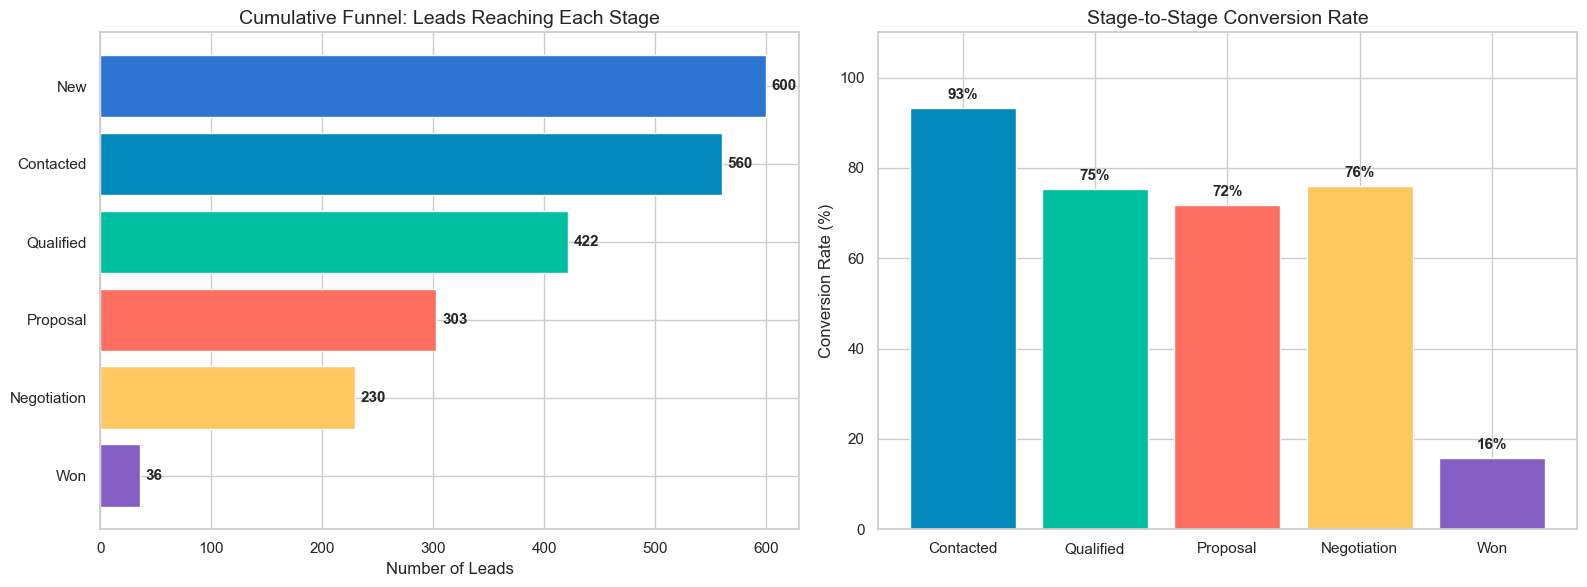

In [5]:
# Funnel visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Funnel bar chart
bars = axes[0].barh(funnel_df['stage'][::-1], funnel_df['reached_count'][::-1], color=NEXUS_COLORS[:6][::-1])
axes[0].set_xlabel('Number of Leads')
axes[0].set_title('Cumulative Funnel: Leads Reaching Each Stage')
for bar, val in zip(bars, funnel_df['reached_count'][::-1]):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontweight='bold')

# Right: Stage-to-stage conversion rates
conv_data = funnel_df.dropna(subset=['stage_conversion'])
axes[1].bar(conv_data['stage'], conv_data['stage_conversion'], color=NEXUS_COLORS[1:6])
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Stage-to-Stage Conversion Rate')
axes[1].set_ylim(0, 110)
for i, (_, row) in enumerate(conv_data.iterrows()):
    axes[1].text(i, row['stage_conversion'] + 2, f"{row['stage_conversion']:.0f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Q2: Channel Performance
*Which lead sources produce the highest volume? The highest conversion rate? The highest average deal value? Are any channels underperforming?*

In [6]:
# --- Q2: Channel Performance ---

channel_stats = df.groupby('lead_source').agg(
    total_leads=('lead_id', 'count'),
    won=('status', lambda x: (x == 'Won').sum()),
    lost=('status', lambda x: (x == 'Lost').sum()),
    avg_deal_value=('deal_value', 'mean'),
    total_deal_value=('deal_value', 'sum'),
    avg_lead_score=('lead_score', 'mean'),
    avg_response_hours=('days_to_first_contact', 'mean'),
).reset_index()

channel_stats['win_rate_all'] = (channel_stats['won'] / channel_stats['total_leads'] * 100).round(1)
channel_stats['win_rate_closed'] = (channel_stats['won'] / (channel_stats['won'] + channel_stats['lost']) * 100).round(1)
channel_stats['loss_rate'] = (channel_stats['lost'] / channel_stats['total_leads'] * 100).round(1)
channel_stats['revenue_per_lead'] = (channel_stats['total_deal_value'] / channel_stats['total_leads']).round(0)
channel_stats = channel_stats.sort_values('total_leads', ascending=False)

display_cols = ['lead_source', 'total_leads', 'won', 'lost', 'win_rate_all', 'win_rate_closed',
                'avg_deal_value', 'avg_lead_score', 'avg_response_hours']
print("=== Channel Performance Summary ===")
print(channel_stats[display_cols].to_string(index=False, float_format='%.1f'))

=== Channel Performance Summary ===


     lead_source  total_leads  won  lost  win_rate_all  win_rate_closed  avg_deal_value  avg_lead_score  avg_response_hours
      Google Ads          108    6    21           5.6             22.2         51925.9            53.6                20.9
    LinkedIn Ads          101    1    30           1.0              3.2         54328.7            53.3                21.5
      Cold Email           89    5    25           5.6             16.7         33151.7            42.6                26.9
         Webinar           81    5    18           6.2             21.7         52066.7            51.8                22.7
  Organic Search           79    4    24           5.1             14.3         58031.6            51.8                21.0
Content Download           51    3     9           5.9             25.0         51578.4            57.9                18.9
        Referral           46    8     5          17.4             61.5         39104.3            66.3                 7.2
      T

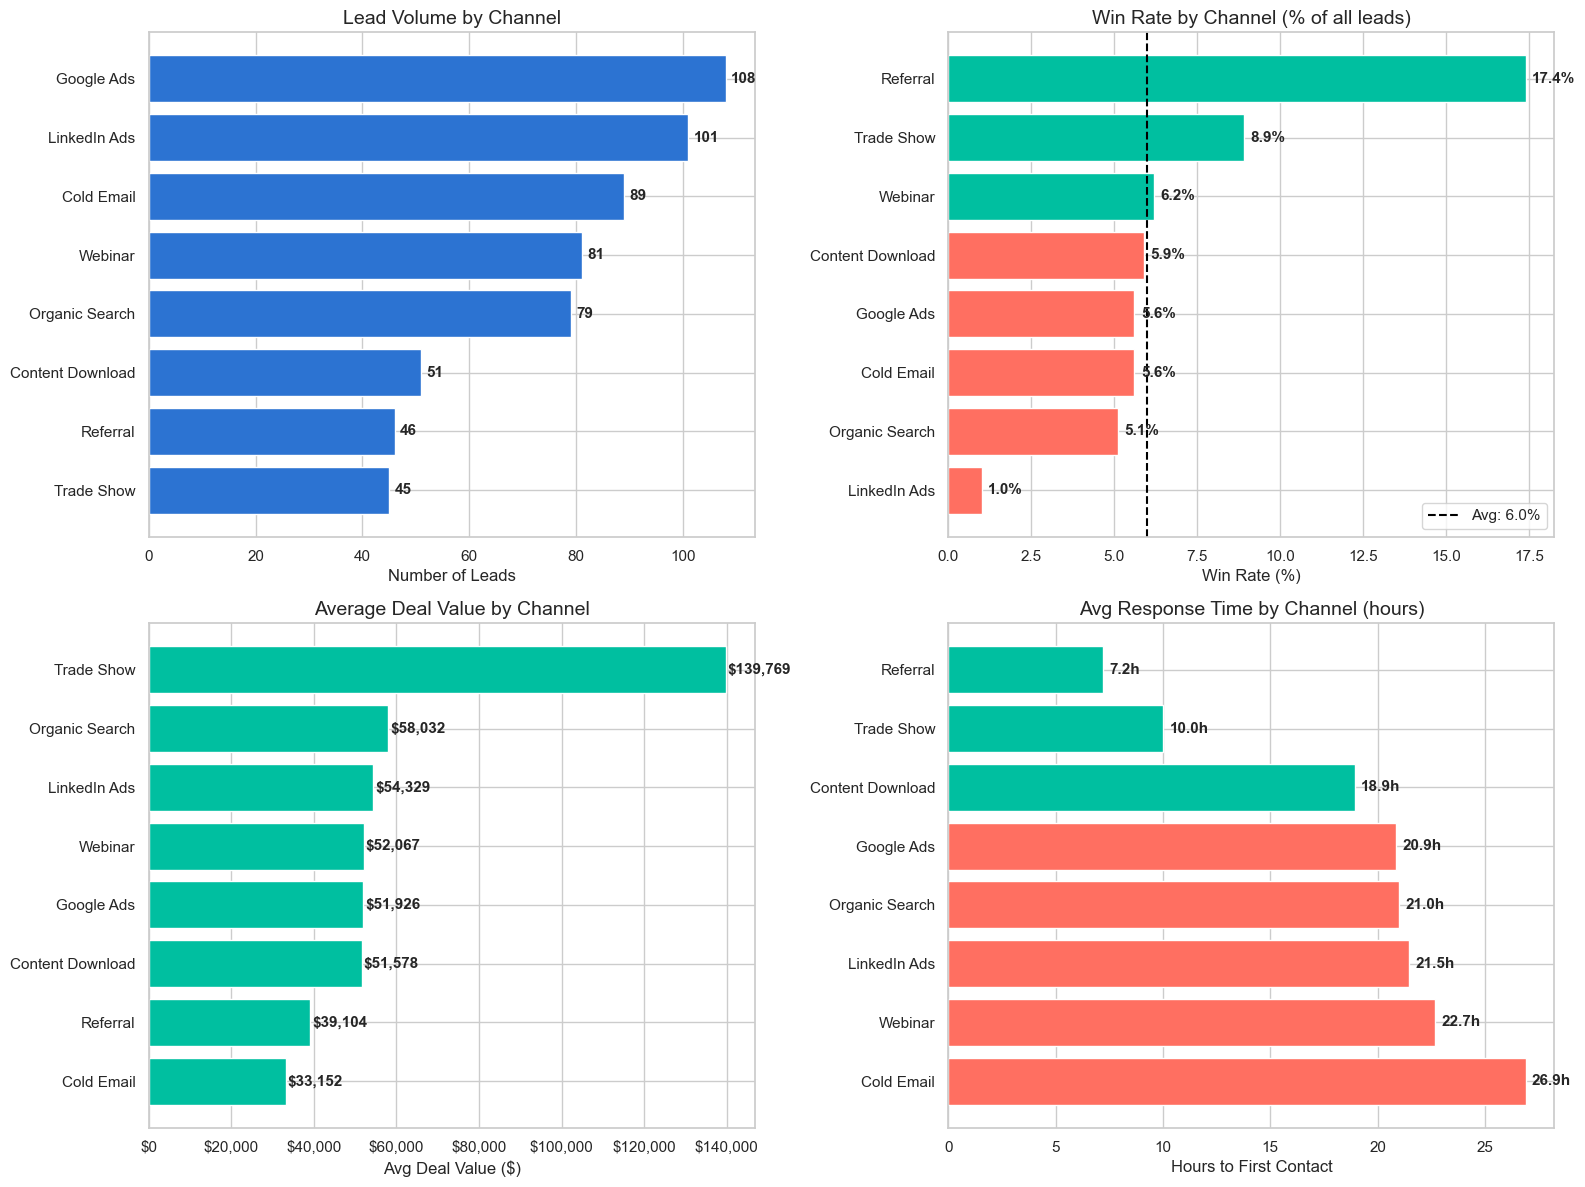

In [7]:
# Channel performance visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cs = channel_stats.sort_values('total_leads', ascending=True)

# Volume
axes[0, 0].barh(cs['lead_source'], cs['total_leads'], color=NEXUS_COLORS[0])
axes[0, 0].set_title('Lead Volume by Channel')
axes[0, 0].set_xlabel('Number of Leads')
for i, v in enumerate(cs['total_leads']):
    axes[0, 0].text(v + 1, i, str(v), va='center', fontweight='bold')

# Win rate (of all leads)
cs_wr = channel_stats.sort_values('win_rate_all', ascending=True)
colors_wr = ['#FF6F61' if x < win_rate_overall else '#00BFA0' for x in cs_wr['win_rate_all']]
axes[0, 1].barh(cs_wr['lead_source'], cs_wr['win_rate_all'], color=colors_wr)
axes[0, 1].axvline(x=win_rate_overall, color='black', linestyle='--', label=f'Avg: {win_rate_overall:.1f}%')
axes[0, 1].set_title('Win Rate by Channel (% of all leads)')
axes[0, 1].set_xlabel('Win Rate (%)')
axes[0, 1].legend()
for i, v in enumerate(cs_wr['win_rate_all']):
    axes[0, 1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')

# Avg deal value
cs_dv = channel_stats.sort_values('avg_deal_value', ascending=True)
axes[1, 0].barh(cs_dv['lead_source'], cs_dv['avg_deal_value'], color=NEXUS_COLORS[2])
axes[1, 0].set_title('Average Deal Value by Channel')
axes[1, 0].set_xlabel('Avg Deal Value ($)')
axes[1, 0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(cs_dv['avg_deal_value']):
    axes[1, 0].text(v + 500, i, f'${v:,.0f}', va='center', fontweight='bold')

# Avg response time (hours)
cs_rt = channel_stats.sort_values('avg_response_hours', ascending=False)
colors_rt = ['#FF6F61' if x > df['days_to_first_contact'].mean() else '#00BFA0' for x in cs_rt['avg_response_hours']]
axes[1, 1].barh(cs_rt['lead_source'], cs_rt['avg_response_hours'], color=colors_rt)
axes[1, 1].set_title('Avg Response Time by Channel (hours)')
axes[1, 1].set_xlabel('Hours to First Contact')
for i, v in enumerate(cs_rt['avg_response_hours']):
    axes[1, 1].text(v + 0.3, i, f'{v:.1f}h', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Q3: Campaign Deep Dive
*Within each channel, which specific campaigns are top performers? Are there campaigns to pause or scale?*

In [8]:
# --- Q3: Campaign Deep Dive ---

campaign_stats = df.groupby(['lead_source', 'campaign_name']).agg(
    total_leads=('lead_id', 'count'),
    won=('status', lambda x: (x == 'Won').sum()),
    lost=('status', lambda x: (x == 'Lost').sum()),
    avg_deal_value=('deal_value', 'mean'),
    avg_lead_score=('lead_score', 'mean'),
    avg_response_hours=('days_to_first_contact', 'mean'),
).reset_index()

campaign_stats['win_rate'] = (campaign_stats['won'] / campaign_stats['total_leads'] * 100).round(1)
campaign_stats['closed'] = campaign_stats['won'] + campaign_stats['lost']
campaign_stats['win_rate_closed'] = np.where(
    campaign_stats['closed'] > 0,
    (campaign_stats['won'] / campaign_stats['closed'] * 100).round(1),
    0
)
campaign_stats = campaign_stats.sort_values(['lead_source', 'win_rate'], ascending=[True, False])

print("=== Campaign Performance (all campaigns) ===")
print(campaign_stats[['lead_source', 'campaign_name', 'total_leads', 'won', 'lost', 
                        'win_rate', 'avg_deal_value', 'avg_lead_score']].to_string(index=False, float_format='%.1f'))

# Flag campaigns to scale or pause
print("\n=== SCALE: Top campaigns (win rate > 10% AND >= 5 leads) ===")
scale = campaign_stats[(campaign_stats['win_rate'] > 10) & (campaign_stats['total_leads'] >= 5)]
print(scale[['campaign_name', 'lead_source', 'total_leads', 'won', 'win_rate', 'avg_deal_value']].to_string(index=False, float_format='%.1f'))

print("\n=== PAUSE: Campaigns with 0 wins AND >= 10 leads ===")
pause = campaign_stats[(campaign_stats['won'] == 0) & (campaign_stats['total_leads'] >= 10)]
print(pause[['campaign_name', 'lead_source', 'total_leads', 'won', 'lost', 'avg_deal_value']].to_string(index=False, float_format='%.1f'))

=== Campaign Performance (all campaigns) ===
     lead_source              campaign_name  total_leads  won  lost  win_rate  avg_deal_value  avg_lead_score
      Cold Email         ColdEmail_Series_A           24    2    11       8.3         33345.8            44.0
      Cold Email  ColdEmail_Enterprise_Push           21    1     6       4.8         50009.5            41.5
      Cold Email    ColdEmail_Re_Engagement           21    1     3       4.8         18423.8            40.7
      Cold Email   ColdEmail_Vertical_Blast           23    1     5       4.3         31004.3            43.8
Content Download      Content_Template_Pack            9    2     0      22.2         28477.8            54.3
Content Download     Content_ROI_Calculator           11    1     2       9.1         56663.6            58.8
Content Download    Content_Ebook_Analytics           16    0     6       0.0         36487.5            52.8
Content Download      Content_Whitepaper_AI           15    0     1       0

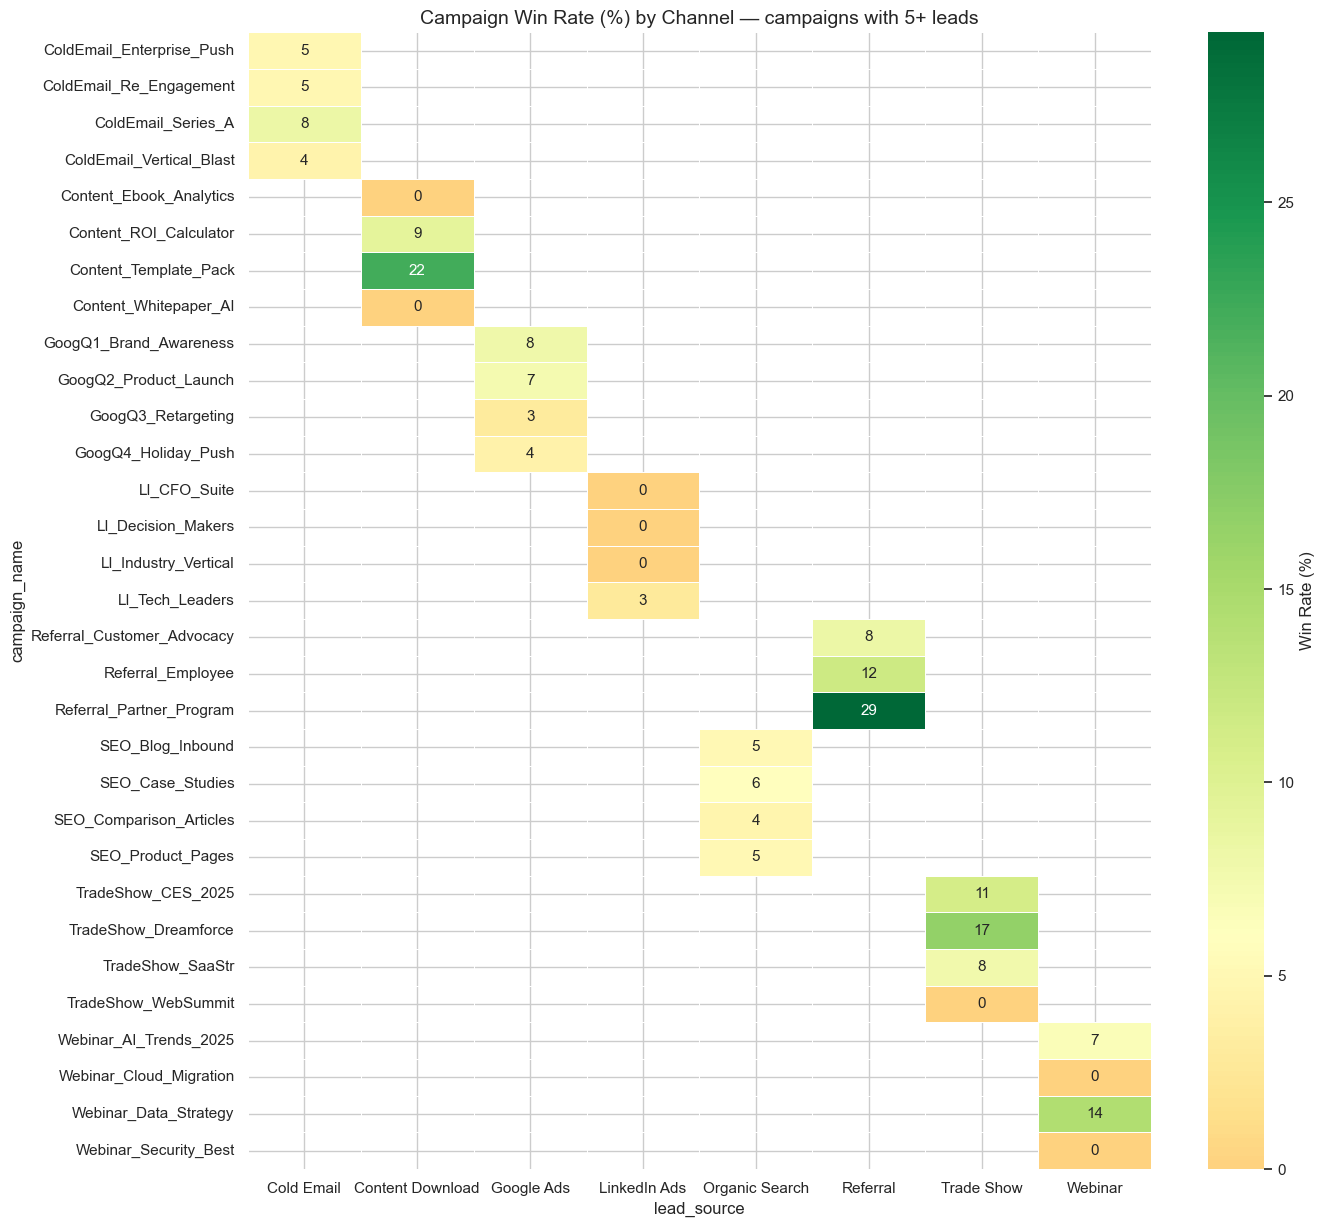

In [9]:
# Campaign heatmap: win rate by campaign (filtered to campaigns with >= 5 leads)
camp_pivot = campaign_stats[campaign_stats['total_leads'] >= 5].copy()
camp_pivot = camp_pivot.pivot_table(index='campaign_name', columns='lead_source', values='win_rate', aggfunc='first')

fig, ax = plt.subplots(figsize=(14, max(8, len(camp_pivot) * 0.4)))
sns.heatmap(camp_pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=win_rate_overall,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Win Rate (%)'})
ax.set_title('Campaign Win Rate (%) by Channel — campaigns with 5+ leads')
plt.tight_layout()
plt.show()

---
## Q4: Sales Rep Performance
*How do conversion rates, response times, and deal values differ across reps? Is there a rep who needs coaching?*

In [10]:
# --- Q4: Sales Rep Performance ---

rep_stats = df.groupby('assigned_rep').agg(
    total_leads=('lead_id', 'count'),
    won=('status', lambda x: (x == 'Won').sum()),
    lost=('status', lambda x: (x == 'Lost').sum()),
    avg_deal_value=('deal_value', 'mean'),
    total_revenue_won=('deal_value', lambda x: x[df.loc[x.index, 'status'] == 'Won'].sum()),
    avg_lead_score=('lead_score', 'mean'),
    avg_response_hours=('days_to_first_contact', 'mean'),
    median_response_hours=('days_to_first_contact', 'median'),
    avg_cycle_days=('cycle_days', 'mean'),
).reset_index()

rep_stats['win_rate_all'] = (rep_stats['won'] / rep_stats['total_leads'] * 100).round(1)
rep_stats['closed'] = rep_stats['won'] + rep_stats['lost']
rep_stats['win_rate_closed'] = np.where(
    rep_stats['closed'] > 0,
    (rep_stats['won'] / rep_stats['closed'] * 100).round(1),
    0
)
rep_stats['pipeline_open'] = rep_stats['total_leads'] - rep_stats['won'] - rep_stats['lost']

rep_stats = rep_stats.sort_values('win_rate_all', ascending=False)

print("=== Sales Rep Performance Summary ===")
print(rep_stats[['assigned_rep', 'total_leads', 'won', 'lost', 'pipeline_open',
                  'win_rate_all', 'win_rate_closed', 'avg_deal_value', 
                  'avg_response_hours', 'avg_cycle_days']].to_string(index=False, float_format='%.1f'))

=== Sales Rep Performance Summary ===
   assigned_rep  total_leads  won  lost  pipeline_open  win_rate_all  win_rate_closed  avg_deal_value  avg_response_hours  avg_cycle_days
     Sarah Chen          101   12    18             71          11.9             40.0         44651.5                 7.5            52.5
Emily Rodriguez          108   11    27             70          10.2             28.9         36927.8                12.6            51.2
  Olivia Foster           93    5    27             61           5.4             15.6         39557.0                20.5            56.9
 James Morrison           97    3    23             71           3.1             11.5         37004.1                18.2            62.0
    Marcus Webb          116    3    25             88           2.6             10.7        128916.4                41.4            77.2
     David Park           85    2    23             60           2.4              8.0         33482.4                17.2            6

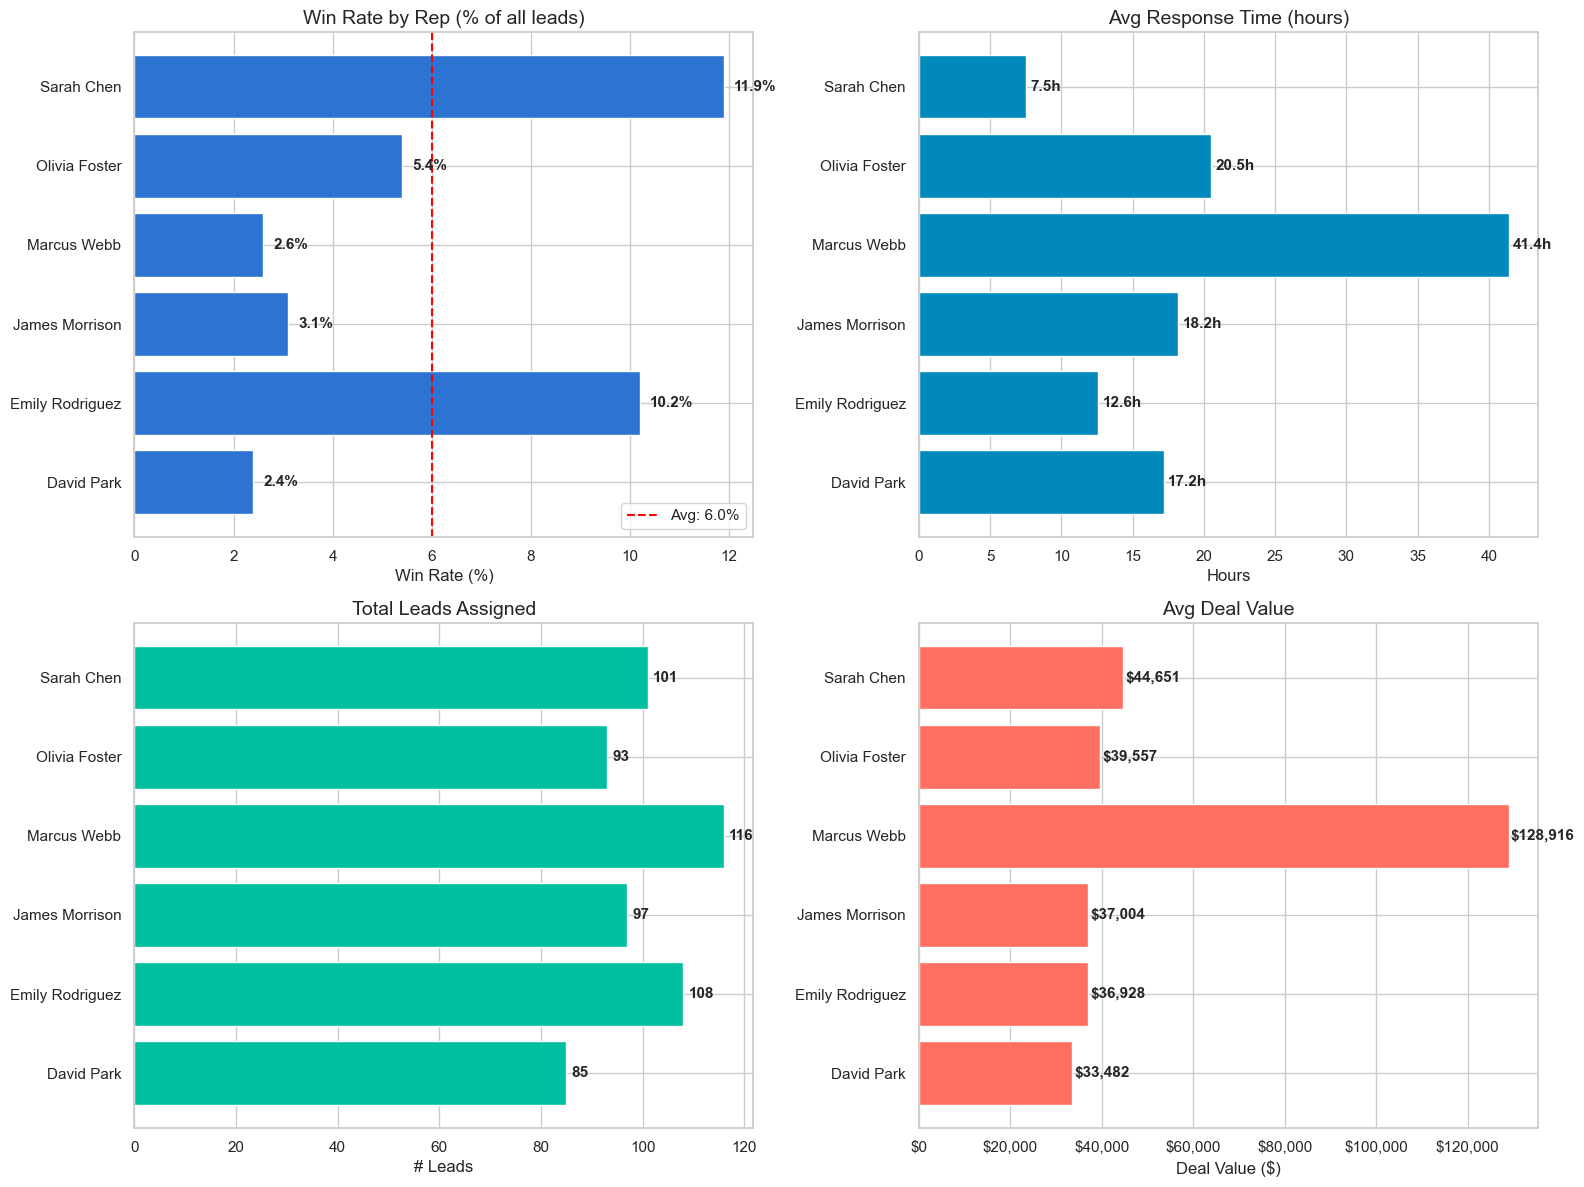

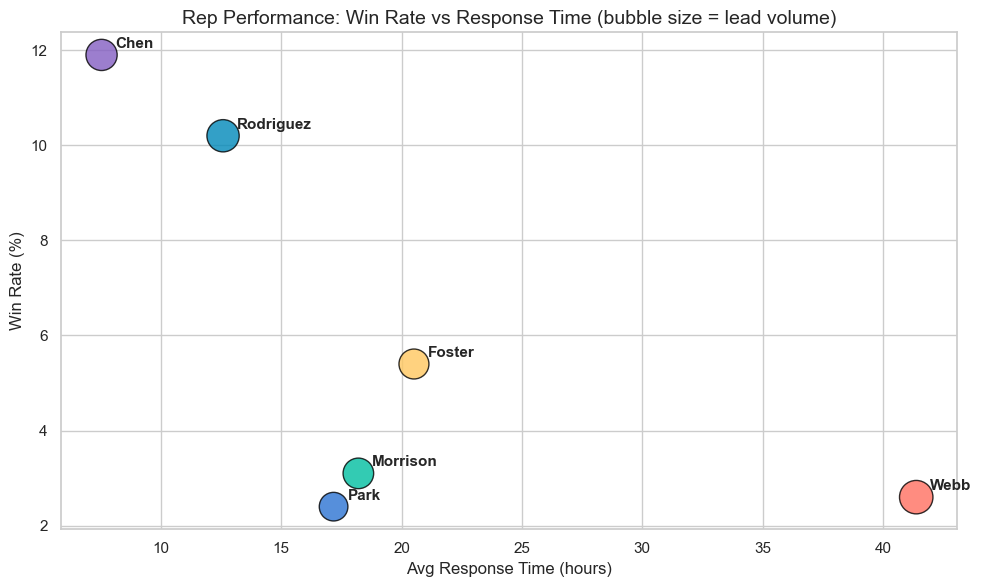

In [11]:
# Rep performance radar-style comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

rs = rep_stats.sort_values('assigned_rep')

# Win rate comparison
axes[0, 0].barh(rs['assigned_rep'], rs['win_rate_all'], color=NEXUS_COLORS[0])
axes[0, 0].axvline(x=win_rate_overall, color='red', linestyle='--', label=f'Avg: {win_rate_overall:.1f}%')
axes[0, 0].set_title('Win Rate by Rep (% of all leads)')
axes[0, 0].set_xlabel('Win Rate (%)')
axes[0, 0].legend()
for i, v in enumerate(rs['win_rate_all']):
    axes[0, 0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')

# Avg response time
axes[0, 1].barh(rs['assigned_rep'], rs['avg_response_hours'], color=NEXUS_COLORS[1])
axes[0, 1].set_title('Avg Response Time (hours)')
axes[0, 1].set_xlabel('Hours')
for i, v in enumerate(rs['avg_response_hours']):
    axes[0, 1].text(v + 0.3, i, f'{v:.1f}h', va='center', fontweight='bold')

# Lead volume
axes[1, 0].barh(rs['assigned_rep'], rs['total_leads'], color=NEXUS_COLORS[2])
axes[1, 0].set_title('Total Leads Assigned')
axes[1, 0].set_xlabel('# Leads')
for i, v in enumerate(rs['total_leads']):
    axes[1, 0].text(v + 1, i, str(v), va='center', fontweight='bold')

# Avg deal value
axes[1, 1].barh(rs['assigned_rep'], rs['avg_deal_value'], color=NEXUS_COLORS[3])
axes[1, 1].set_title('Avg Deal Value')
axes[1, 1].set_xlabel('Deal Value ($)')
axes[1, 1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(rs['avg_deal_value']):
    axes[1, 1].text(v + 500, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Cross-reference: rep win rate vs response time scatter
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(rs['avg_response_hours'], rs['win_rate_all'], 
                     s=rs['total_leads'] * 5, c=NEXUS_COLORS[:len(rs)], alpha=0.8, edgecolors='black')
for _, row in rs.iterrows():
    ax.annotate(row['assigned_rep'].split()[-1], 
                (row['avg_response_hours'], row['win_rate_all']),
                textcoords="offset points", xytext=(10, 5), fontweight='bold')
ax.set_xlabel('Avg Response Time (hours)')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Rep Performance: Win Rate vs Response Time (bubble size = lead volume)')
plt.tight_layout()
plt.show()

---
## Q5: Response Time Impact
*What is the relationship between `days_to_first_contact` (hours) and conversion? Is there a critical threshold?*

=== Win Rate by Response Time Bucket ===
response_bucket  total_leads  won  lost  win_rate  win_rate_closed  avg_deal_value
           0-4h          104    8    22       7.7             26.7         42174.0
           5-8h           85    6    16       7.1             27.3         48435.3
          9-12h           62    4    16       6.5             20.0         43161.3
         13-24h          163   10    39       6.1             20.4         36884.0
         25-36h           87    3    23       3.4             11.5         59075.9
         37-48h           52    4    15       7.7             21.1         96680.8
           48h+           47    1    12       2.1              7.7        132091.5


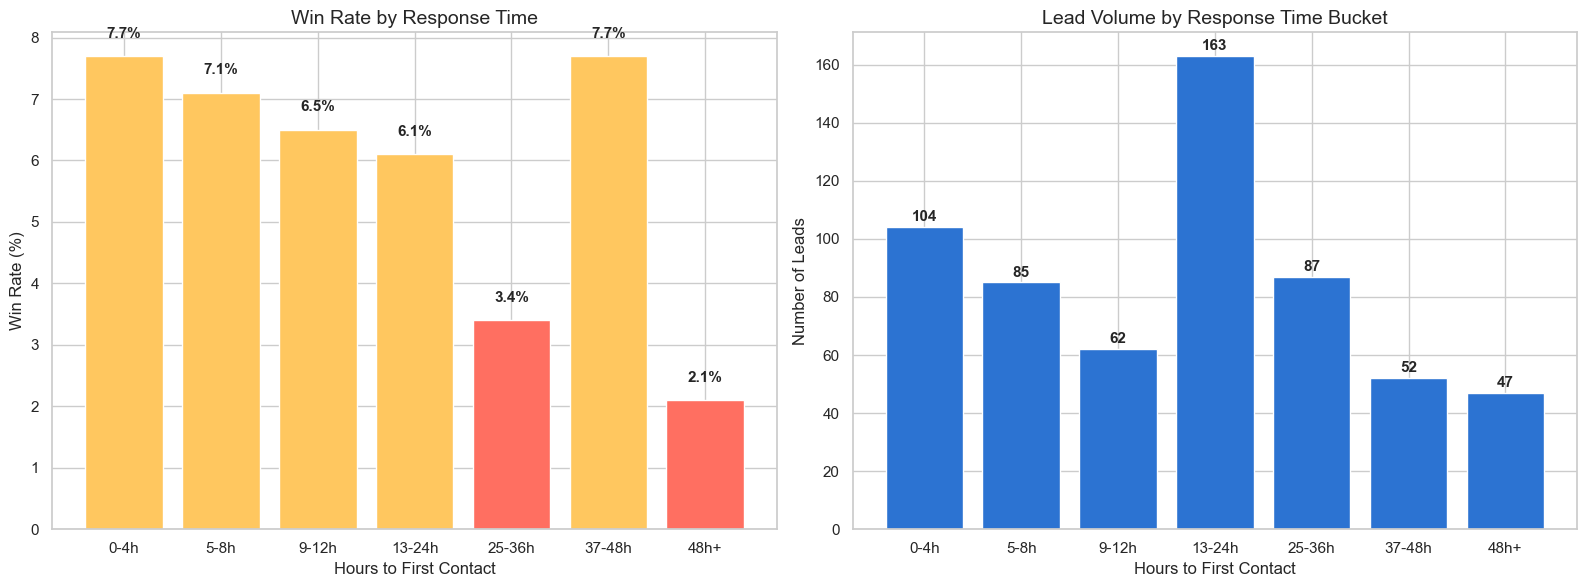


Avg response time — Won leads: 16.1 hours | Lost leads: 21.9 hours
Difference: 5.9 hours slower for lost leads


In [12]:
# --- Q5: Response Time Impact ---

# Create hour buckets
bins = [0, 4, 8, 12, 24, 36, 48, 100]
labels = ['0-4h', '5-8h', '9-12h', '13-24h', '25-36h', '37-48h', '48h+']
df['response_bucket'] = pd.cut(df['days_to_first_contact'], bins=bins, labels=labels, include_lowest=True)

response_stats = df.groupby('response_bucket', observed=False).agg(
    total_leads=('lead_id', 'count'),
    won=('status', lambda x: (x == 'Won').sum()),
    lost=('status', lambda x: (x == 'Lost').sum()),
    avg_deal_value=('deal_value', 'mean'),
    avg_lead_score=('lead_score', 'mean'),
).reset_index()

response_stats['win_rate'] = (response_stats['won'] / response_stats['total_leads'] * 100).round(1)
response_stats['closed'] = response_stats['won'] + response_stats['lost']
response_stats['win_rate_closed'] = np.where(
    response_stats['closed'] > 0,
    (response_stats['won'] / response_stats['closed'] * 100).round(1),
    0
)

print("=== Win Rate by Response Time Bucket ===")
print(response_stats[['response_bucket', 'total_leads', 'won', 'lost', 'win_rate', 
                        'win_rate_closed', 'avg_deal_value']].to_string(index=False, float_format='%.1f'))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Win rate by bucket
colors = ['#00BFA0' if x >= 10 else '#FFC75F' if x >= 5 else '#FF6F61' for x in response_stats['win_rate']]
axes[0].bar(response_stats['response_bucket'].astype(str), response_stats['win_rate'], color=colors)
axes[0].set_xlabel('Hours to First Contact')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_title('Win Rate by Response Time')
for i, v in enumerate(response_stats['win_rate']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Volume by bucket
axes[1].bar(response_stats['response_bucket'].astype(str), response_stats['total_leads'], color=NEXUS_COLORS[0])
axes[1].set_xlabel('Hours to First Contact')
axes[1].set_ylabel('Number of Leads')
axes[1].set_title('Lead Volume by Response Time Bucket')
for i, v in enumerate(response_stats['total_leads']):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical check: average response time for Won vs Lost
won_resp = df[df['status'] == 'Won']['days_to_first_contact'].mean()
lost_resp = df[df['status'] == 'Lost']['days_to_first_contact'].mean()
print(f"\nAvg response time — Won leads: {won_resp:.1f} hours | Lost leads: {lost_resp:.1f} hours")
print(f"Difference: {lost_resp - won_resp:.1f} hours slower for lost leads")

---
## Q6: Lead Scoring Accuracy
*Do higher lead scores correlate with higher conversion rates? Does this hold across all industries?*

=== Lead Score vs Win Rate (Overall) ===
score_bracket  total_leads  won  lost  win_rate
         0-20           22    2     6       9.1
        21-40          136   13    35       9.6
        41-60          233    9    60       3.9
        61-80          173    9    37       5.2
       81-100           36    3     5       8.3

=== Win Rate by Industry x Score Bracket (NaN = <3 leads) ===
score_bracket  0-20  21-40  41-60  61-80  81-100
industry                                        
Education       NaN    0.0    7.7    0.0    33.3
Finance         NaN    6.7    0.0    4.3     0.0
Healthcare     16.7    4.3    2.3    7.7     NaN
Manufacturing   NaN   18.8    7.7   12.5     0.0
Real Estate     NaN    8.3    0.0    0.0    33.3
Retail         14.3   13.8    4.4    4.8     0.0
Technology      0.0   10.7    4.5    5.9     8.3


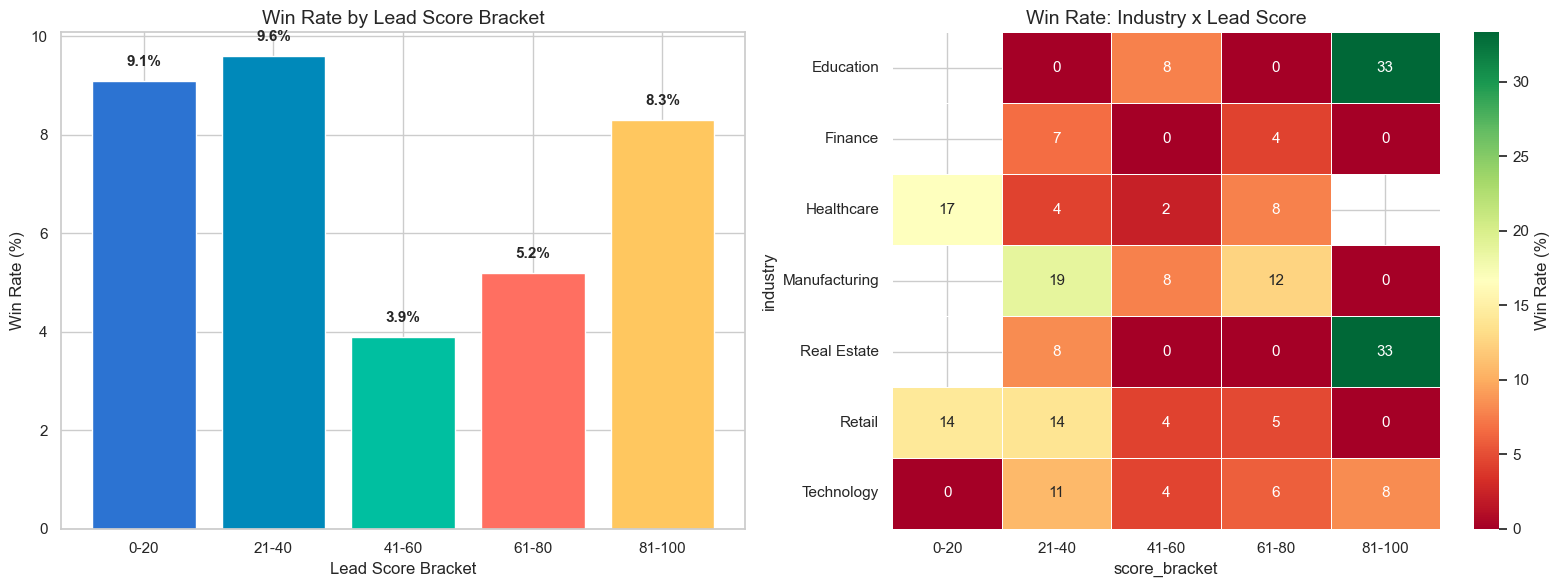

In [13]:
# --- Q6: Lead Scoring Accuracy ---

# Score brackets
score_bins = [0, 20, 40, 60, 80, 100]
score_labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
df['score_bracket'] = pd.cut(df['lead_score'], bins=score_bins, labels=score_labels, include_lowest=True)

# Overall: score bracket vs win rate
score_stats = df.groupby('score_bracket', observed=False).agg(
    total_leads=('lead_id', 'count'),
    won=('status', lambda x: (x == 'Won').sum()),
    lost=('status', lambda x: (x == 'Lost').sum()),
    avg_deal_value=('deal_value', 'mean'),
).reset_index()
score_stats['win_rate'] = (score_stats['won'] / score_stats['total_leads'] * 100).round(1)

print("=== Lead Score vs Win Rate (Overall) ===")
print(score_stats[['score_bracket', 'total_leads', 'won', 'lost', 'win_rate']].to_string(index=False))

# Cross-tab: score bracket by industry
cross_tab = df.groupby(['industry', 'score_bracket'], observed=False).agg(
    total=('lead_id', 'count'),
    won=('status', lambda x: (x == 'Won').sum()),
).reset_index()
cross_tab['win_rate'] = np.where(cross_tab['total'] >= 3, 
                                  (cross_tab['won'] / cross_tab['total'] * 100).round(1), 
                                  np.nan)

pivot = cross_tab.pivot_table(index='industry', columns='score_bracket', values='win_rate')
print("\n=== Win Rate by Industry x Score Bracket (NaN = <3 leads) ===")
print(pivot.to_string(float_format='%.1f'))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar: overall score vs win rate
axes[0].bar(score_stats['score_bracket'].astype(str), score_stats['win_rate'], color=NEXUS_COLORS[:5])
axes[0].set_xlabel('Lead Score Bracket')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_title('Win Rate by Lead Score Bracket')
for i, v in enumerate(score_stats['win_rate']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Heatmap: industry x score
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Win Rate (%)'})
axes[1].set_title('Win Rate: Industry x Lead Score')

plt.tight_layout()
plt.show()

---
## Q7: Seasonality
*Are there quarterly or monthly trends in lead volume, conversion rates, or deal sizes?*

=== Monthly Trends ===


month_str  total_leads  won  lost  win_rate  avg_deal_value
  2024-01           46    1    10       2.2         56623.9
  2024-02           52    5    16       9.6         52550.0
  2024-03           66    6    12       9.1         69122.7
  2024-04           41    0     7       0.0         45107.3
  2024-05           46    4     7       8.7         47273.9
  2024-06           48    1    10       2.1         38327.1
  2024-07           57    3    19       5.3         52164.9
  2024-08           62    3    16       4.8         67987.1
  2024-09           49    2     7       4.1         58483.7
  2024-10           43    3    13       7.0         48316.3
  2024-11           48    5    13      10.4         65575.0
  2024-12           42    3    13       7.1         60092.9

=== Quarterly Trends ===
quarter_str  total_leads  won  lost  win_rate  avg_deal_value
     2024Q1          164   12    38       7.3         60362.2
     2024Q2          135    5    24       3.7         43434.8
     20

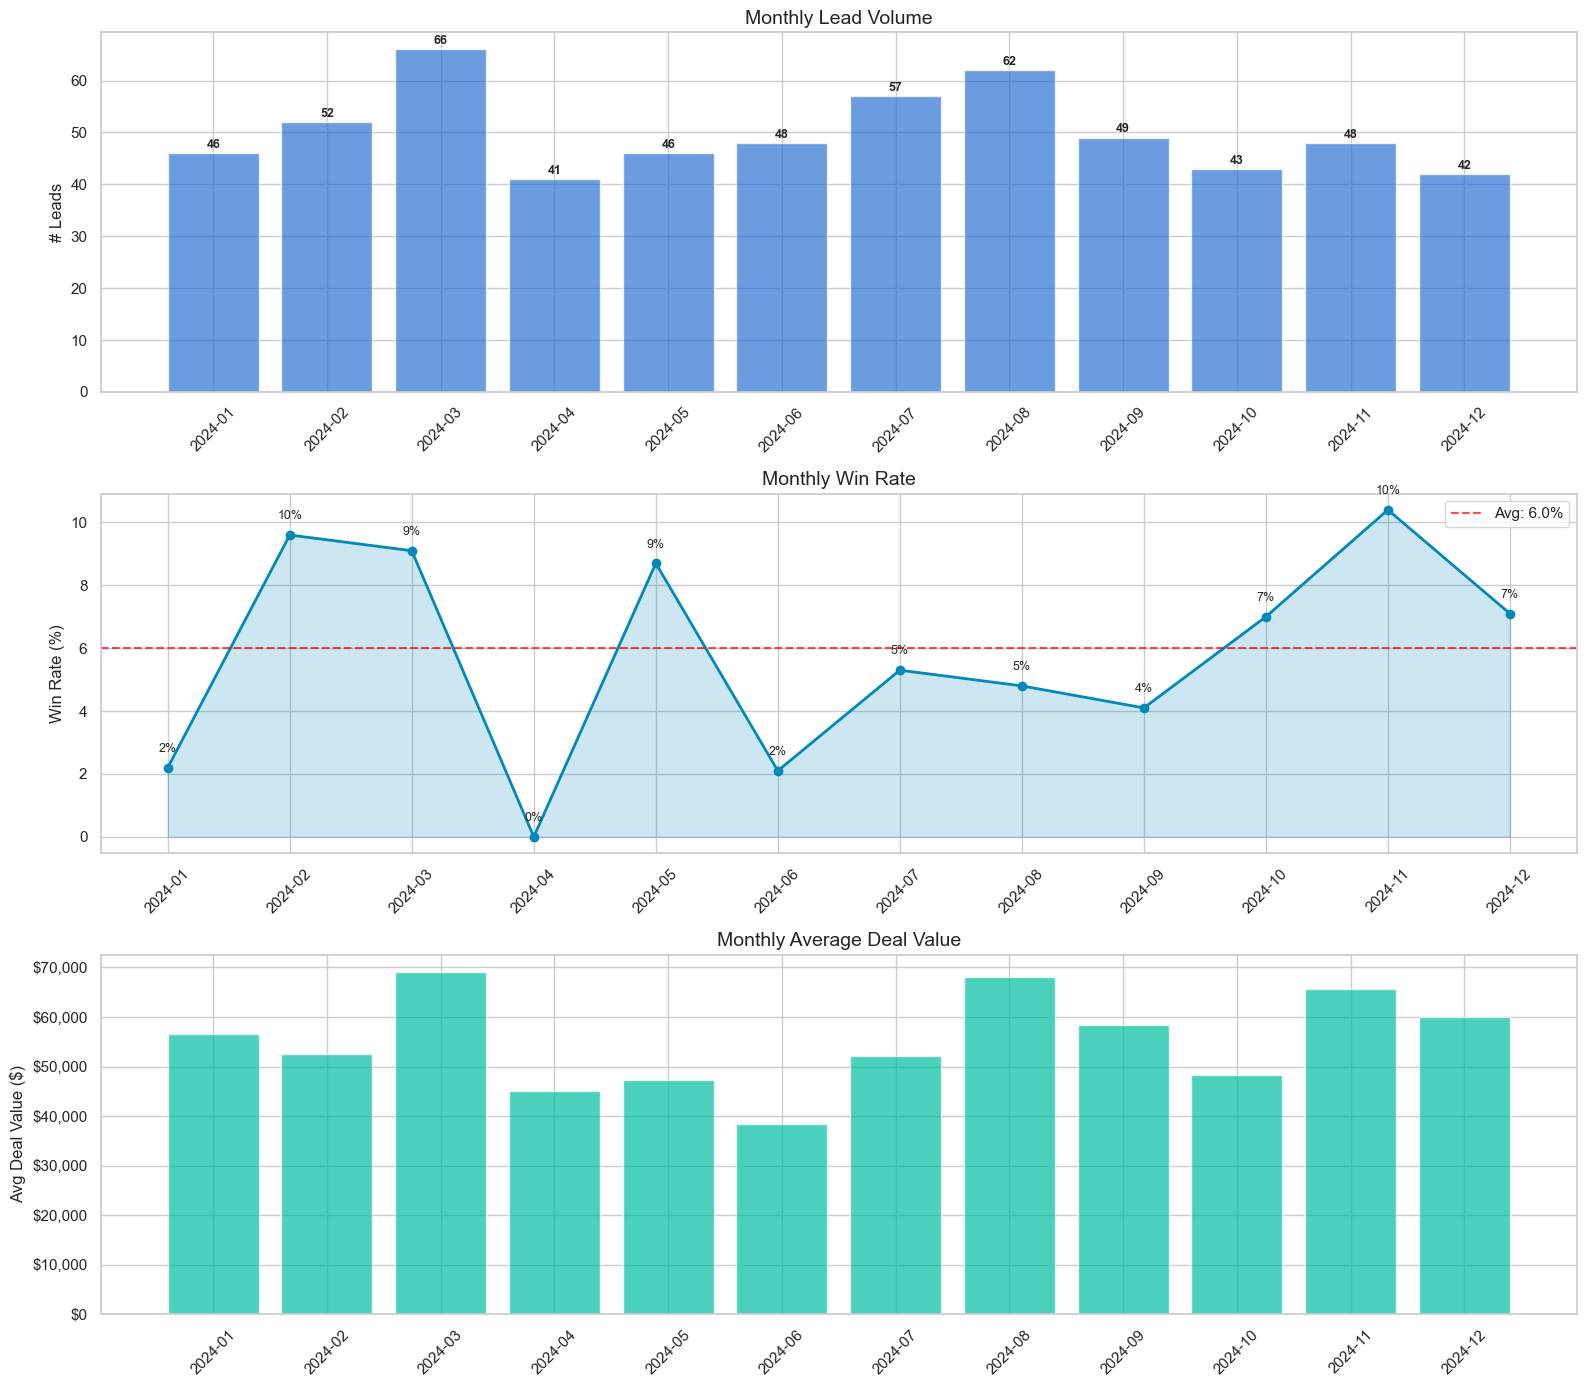

In [14]:
# --- Q7: Seasonality ---

# Monthly trends
monthly = df.groupby('created_month').agg(
    total_leads=('lead_id', 'count'),
    won=('status', lambda x: (x == 'Won').sum()),
    lost=('status', lambda x: (x == 'Lost').sum()),
    avg_deal_value=('deal_value', 'mean'),
    avg_lead_score=('lead_score', 'mean'),
).reset_index()
monthly['win_rate'] = (monthly['won'] / monthly['total_leads'] * 100).round(1)
monthly['month_str'] = monthly['created_month'].astype(str)

print("=== Monthly Trends ===")
print(monthly[['month_str', 'total_leads', 'won', 'lost', 'win_rate', 'avg_deal_value']].to_string(index=False, float_format='%.1f'))

# Quarterly trends
quarterly = df.groupby('created_quarter').agg(
    total_leads=('lead_id', 'count'),
    won=('status', lambda x: (x == 'Won').sum()),
    lost=('status', lambda x: (x == 'Lost').sum()),
    avg_deal_value=('deal_value', 'mean'),
).reset_index()
quarterly['win_rate'] = (quarterly['won'] / quarterly['total_leads'] * 100).round(1)
quarterly['quarter_str'] = quarterly['created_quarter'].astype(str)

print("\n=== Quarterly Trends ===")
print(quarterly[['quarter_str', 'total_leads', 'won', 'lost', 'win_rate', 'avg_deal_value']].to_string(index=False, float_format='%.1f'))

# Visualization
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Monthly volume
axes[0].bar(monthly['month_str'], monthly['total_leads'], color=NEXUS_COLORS[0], alpha=0.7)
axes[0].set_ylabel('# Leads')
axes[0].set_title('Monthly Lead Volume')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(monthly['total_leads']):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=9, fontweight='bold')

# Monthly win rate
axes[1].plot(monthly['month_str'], monthly['win_rate'], marker='o', color=NEXUS_COLORS[1], linewidth=2)
axes[1].fill_between(range(len(monthly)), monthly['win_rate'], alpha=0.2, color=NEXUS_COLORS[1])
axes[1].axhline(y=win_rate_overall, color='red', linestyle='--', alpha=0.7, label=f'Avg: {win_rate_overall:.1f}%')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_title('Monthly Win Rate')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(monthly['win_rate']):
    axes[1].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=9)

# Monthly avg deal value
axes[2].bar(monthly['month_str'], monthly['avg_deal_value'], color=NEXUS_COLORS[2], alpha=0.7)
axes[2].set_ylabel('Avg Deal Value ($)')
axes[2].set_title('Monthly Average Deal Value')
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Q8: Lost Deal Analysis
*What are the most common lost reasons by channel, by rep, and by company size? Are there preventable losses?*

In [15]:
# --- Q8: Lost Deal Analysis ---

lost_df = df[df['status'] == 'Lost'].copy()
print(f"Total lost leads: {len(lost_df)}")
print(f"\n=== Lost Reasons Overall ===")
print(lost_df['lost_reason'].value_counts())

# Lost reasons by channel
print("\n=== Lost Reasons by Channel ===")
lost_by_channel = pd.crosstab(lost_df['lead_source'], lost_df['lost_reason'], margins=True)
print(lost_by_channel)

# Lost reasons by rep
print("\n=== Lost Reasons by Rep ===")
lost_by_rep = pd.crosstab(lost_df['assigned_rep'], lost_df['lost_reason'], margins=True)
print(lost_by_rep)

# Lost reasons by company size
print("\n=== Lost Reasons by Company Size ===")
lost_by_size = pd.crosstab(lost_df['company_size'], lost_df['lost_reason'], margins=True)
print(lost_by_size)

# Revenue lost
print(f"\n=== Total Revenue Lost: ${lost_df['deal_value'].sum():,.0f} ===")
print(f"\nRevenue lost by reason:")
print(lost_df.groupby('lost_reason')['deal_value'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
      .rename(columns={'sum': 'total_lost', 'mean': 'avg_deal', 'count': 'deals'}))

Total lost leads: 143

=== Lost Reasons Overall ===
lost_reason
No Response    44
Competitor     38
Budget         29
Bad Fit        22
Timing         10
Name: count, dtype: int64

=== Lost Reasons by Channel ===
lost_reason       Bad Fit  Budget  Competitor  No Response  Timing  All
lead_source                                                            
Cold Email              1       2           5           17       0   25
Content Download        1       2           4            2       0    9
Google Ads              6       5           3            4       3   21
LinkedIn Ads            4       6           9            9       2   30
Organic Search          3       6           8            4       3   24
Referral                1       2           0            2       0    5
Trade Show              1       2           5            2       1   11
Webinar                 5       4           4            4       1   18
All                    22      29          38           44      10 

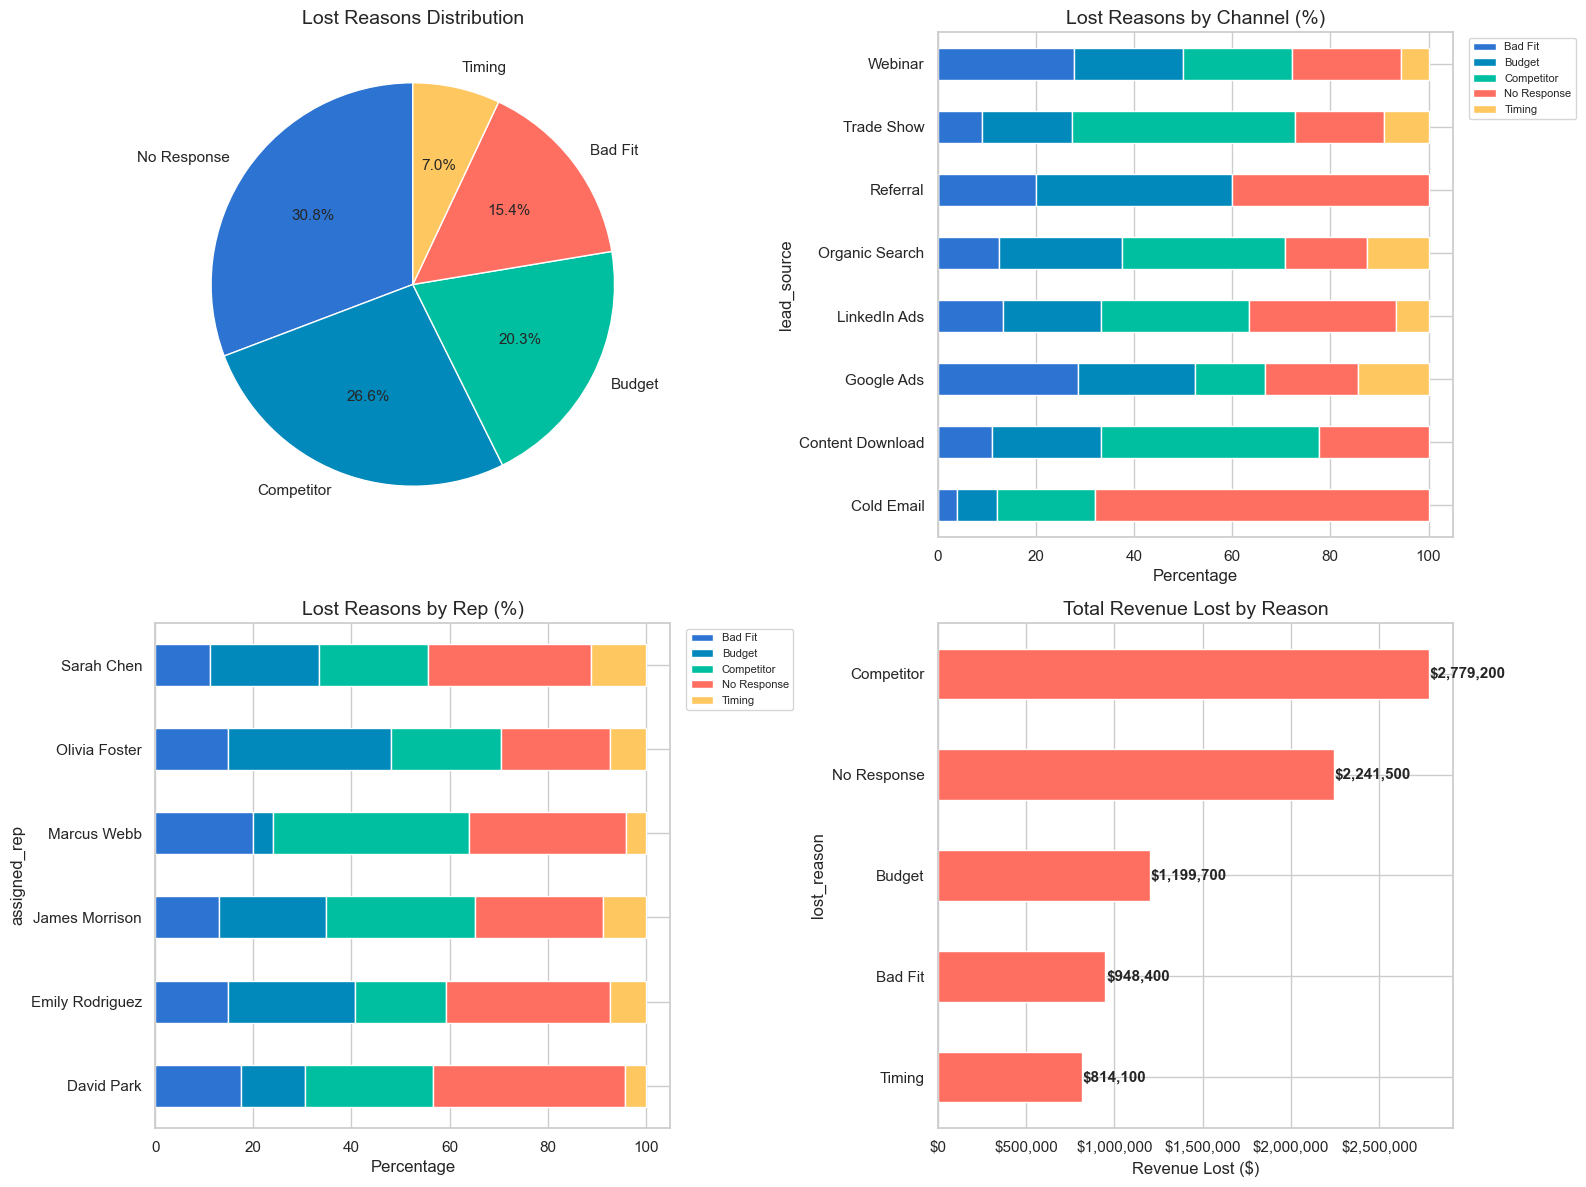

=== Potentially Preventable Losses ===
'No Response' and 'Timing' losses may be preventable with better follow-up processes.
Preventable lost leads: 54 (37.8% of all losses)
Preventable lost revenue: $3,055,600


In [16]:
# Lost deal visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall lost reasons pie
reason_counts = lost_df['lost_reason'].value_counts()
axes[0, 0].pie(reason_counts, labels=reason_counts.index, autopct='%1.1f%%', 
               colors=NEXUS_COLORS[:len(reason_counts)], startangle=90)
axes[0, 0].set_title('Lost Reasons Distribution')

# Lost reasons by channel (stacked bar)
lost_channel_pct = pd.crosstab(lost_df['lead_source'], lost_df['lost_reason'], normalize='index') * 100
lost_channel_pct.plot(kind='barh', stacked=True, ax=axes[0, 1], color=NEXUS_COLORS[:5])
axes[0, 1].set_title('Lost Reasons by Channel (%)')
axes[0, 1].set_xlabel('Percentage')
axes[0, 1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Lost reasons by rep (stacked bar)
lost_rep_pct = pd.crosstab(lost_df['assigned_rep'], lost_df['lost_reason'], normalize='index') * 100
lost_rep_pct.plot(kind='barh', stacked=True, ax=axes[1, 0], color=NEXUS_COLORS[:5])
axes[1, 0].set_title('Lost Reasons by Rep (%)')
axes[1, 0].set_xlabel('Percentage')
axes[1, 0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Revenue lost by reason
rev_by_reason = lost_df.groupby('lost_reason')['deal_value'].sum().sort_values()
rev_by_reason.plot(kind='barh', ax=axes[1, 1], color=NEXUS_COLORS[3])
axes[1, 1].set_title('Total Revenue Lost by Reason')
axes[1, 1].set_xlabel('Revenue Lost ($)')
axes[1, 1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(rev_by_reason):
    axes[1, 1].text(v + 5000, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Preventable losses analysis
print("=== Potentially Preventable Losses ===")
print("'No Response' and 'Timing' losses may be preventable with better follow-up processes.")
preventable = lost_df[lost_df['lost_reason'].isin(['No Response', 'Timing'])]
print(f"Preventable lost leads: {len(preventable)} ({len(preventable)/len(lost_df)*100:.1f}% of all losses)")
print(f"Preventable lost revenue: ${preventable['deal_value'].sum():,.0f}")

---
## Q9: Industry Segmentation
*Which industries convert best? Highest deal values? Which channel-industry combos work well or poorly?*

=== Industry Performance ===
     industry  total_leads  won  lost  win_rate  avg_deal_value  avg_lead_score
Manufacturing           63    7    20      11.1         59093.7            51.6
       Retail          108    8    20       7.4         44098.1            49.7
   Technology          161   10    39       6.2         50905.0            55.7
   Healthcare           98    5    25       5.1         69406.1            49.0
  Real Estate           48    2     9       4.2         46416.7            52.0
    Education           50    2    13       4.0         35810.0            52.8
      Finance           72    2    17       2.8         84236.1            56.0

=== Win Rate: Channel x Industry (NaN = <5 leads) ===
industry          Education  Finance  Healthcare  Manufacturing  Real Estate  Retail  Technology
lead_source                                                                                     
Cold Email              0.0      0.0         0.0            9.1         11.1    17

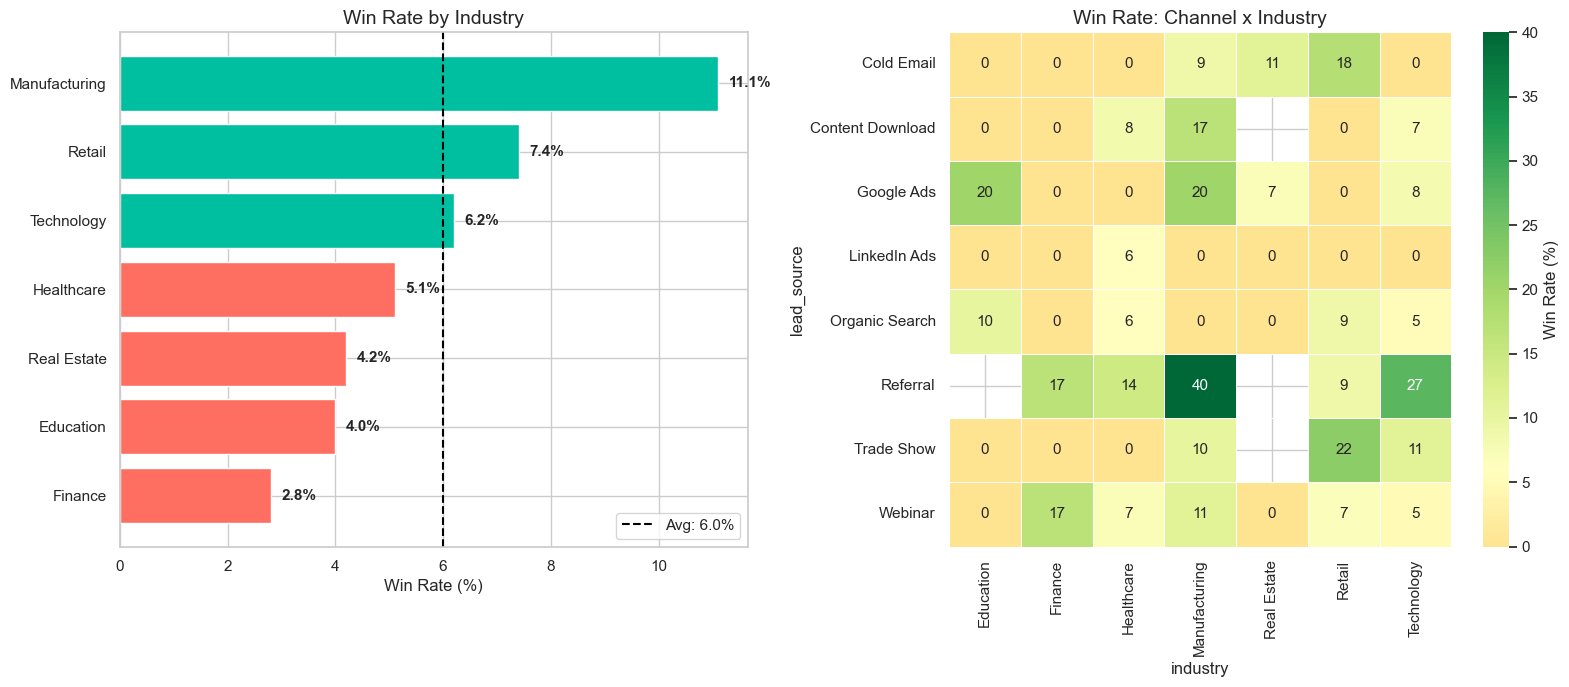

In [17]:
# --- Q9: Industry Segmentation ---

industry_stats = df.groupby('industry').agg(
    total_leads=('lead_id', 'count'),
    won=('status', lambda x: (x == 'Won').sum()),
    lost=('status', lambda x: (x == 'Lost').sum()),
    avg_deal_value=('deal_value', 'mean'),
    total_deal_value=('deal_value', 'sum'),
    avg_lead_score=('lead_score', 'mean'),
    avg_response_hours=('days_to_first_contact', 'mean'),
).reset_index()
industry_stats['win_rate'] = (industry_stats['won'] / industry_stats['total_leads'] * 100).round(1)
industry_stats = industry_stats.sort_values('win_rate', ascending=False)

print("=== Industry Performance ===")
print(industry_stats[['industry', 'total_leads', 'won', 'lost', 'win_rate', 
                        'avg_deal_value', 'avg_lead_score']].to_string(index=False, float_format='%.1f'))

# Channel x Industry cross-tab
channel_industry = df.groupby(['lead_source', 'industry']).agg(
    total=('lead_id', 'count'),
    won=('status', lambda x: (x == 'Won').sum()),
).reset_index()
channel_industry['win_rate'] = np.where(
    channel_industry['total'] >= 5,
    (channel_industry['won'] / channel_industry['total'] * 100).round(1),
    np.nan
)

pivot_ci = channel_industry.pivot_table(index='lead_source', columns='industry', values='win_rate')
print("\n=== Win Rate: Channel x Industry (NaN = <5 leads) ===")
print(pivot_ci.to_string(float_format='%.1f'))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Industry win rate
ind_sorted = industry_stats.sort_values('win_rate', ascending=True)
colors = ['#00BFA0' if x >= win_rate_overall else '#FF6F61' for x in ind_sorted['win_rate']]
axes[0].barh(ind_sorted['industry'], ind_sorted['win_rate'], color=colors)
axes[0].axvline(x=win_rate_overall, color='black', linestyle='--', label=f'Avg: {win_rate_overall:.1f}%')
axes[0].set_title('Win Rate by Industry')
axes[0].set_xlabel('Win Rate (%)')
axes[0].legend()
for i, v in enumerate(ind_sorted['win_rate']):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')

# Heatmap: channel x industry
sns.heatmap(pivot_ci, annot=True, fmt='.0f', cmap='RdYlGn', center=win_rate_overall,
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Win Rate (%)'})
axes[1].set_title('Win Rate: Channel x Industry')

plt.tight_layout()
plt.show()

---
## Q10: Company Size Analysis
*How does company size affect conversion rate, deal value, and cycle length? Are reps handling disproportionate segments?*

=== Company Size Performance ===
      company_size  total_leads  won  lost  win_rate  avg_deal_value  avg_cycle_days  avg_response_hours
      Small (1-50)          167    9    37       5.4          9540.1            58.2                16.9
   Medium (51-200)          211   15    56       7.1         27314.7            57.1                16.4
  Large (201-1000)          123    5    31       4.1         74444.7            59.4                17.2
Enterprise (1000+)           99    7    19       7.1        172254.5            74.3                36.9

=== Lead Distribution: Rep x Company Size ===
company_size     Small (1-50)  Medium (51-200)  Large (201-1000)  \
assigned_rep                                                       
David Park                 25               34                19   
Emily Rodriguez            37               43                20   
James Morrison             26               41                23   
Marcus Webb                23               19         

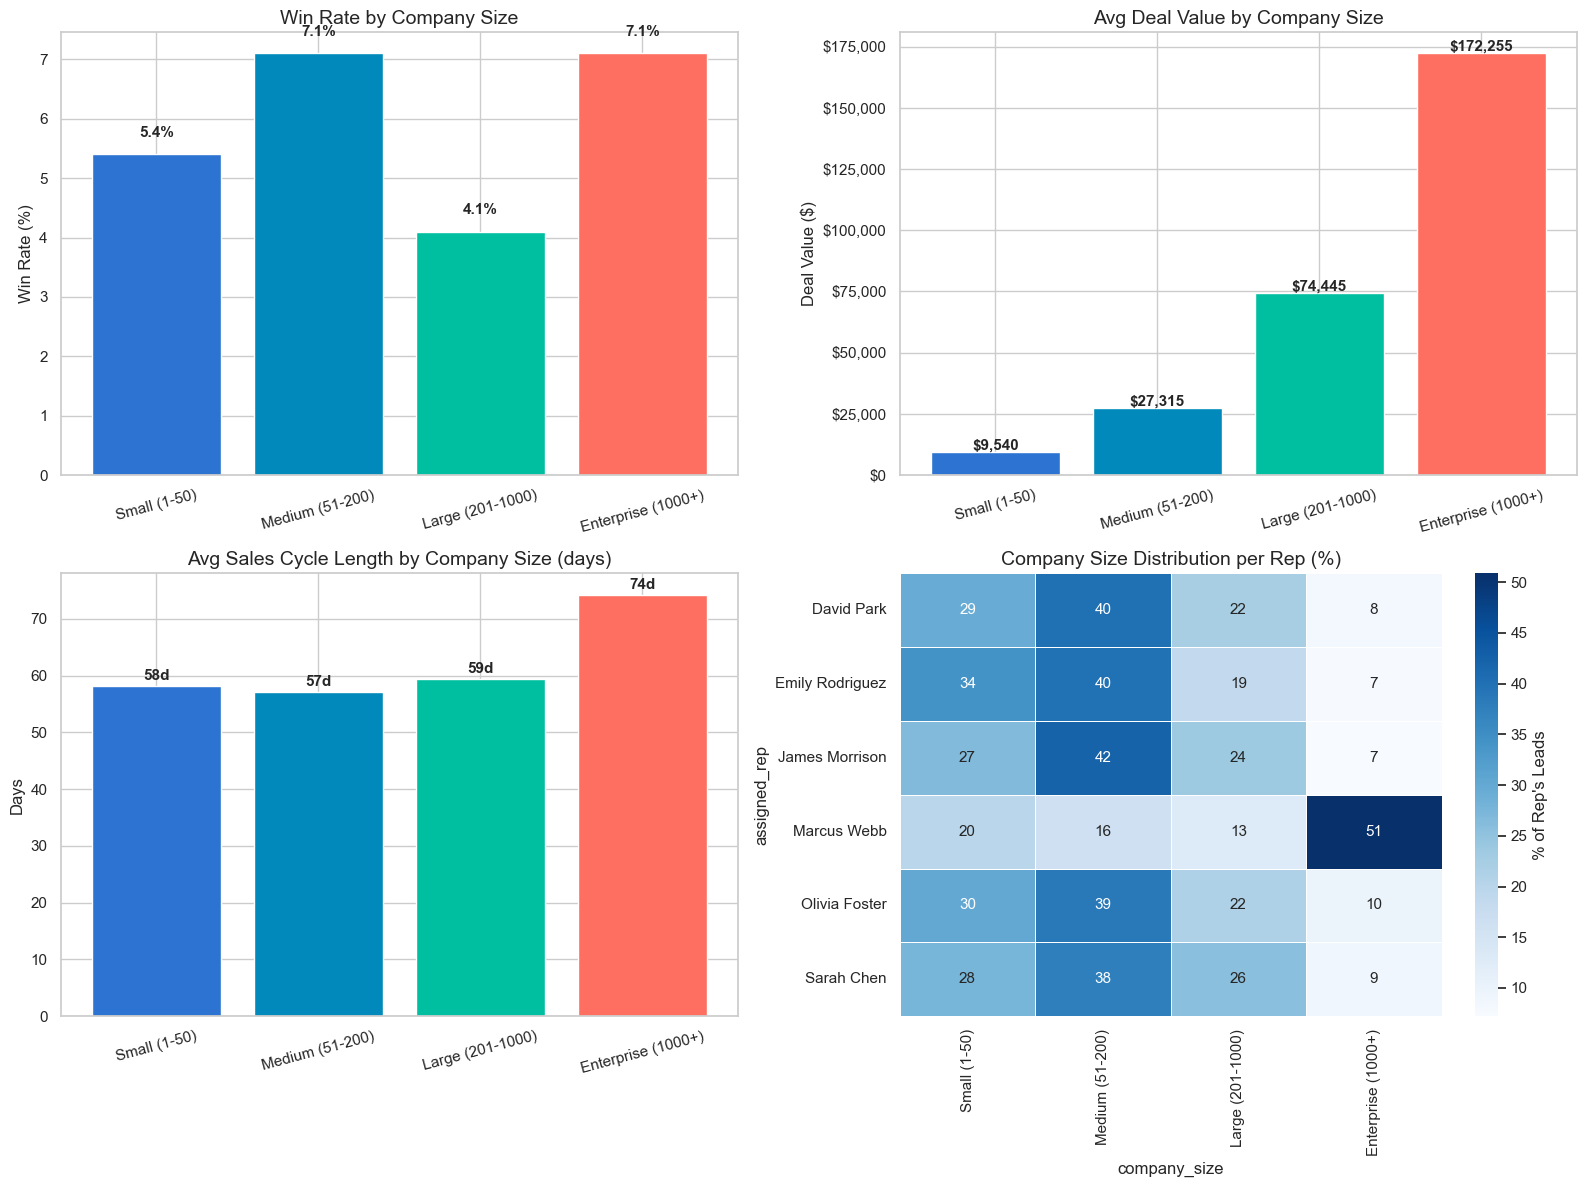

In [18]:
# --- Q10: Company Size Analysis ---

SIZE_ORDER = ['Small (1-50)', 'Medium (51-200)', 'Large (201-1000)', 'Enterprise (1000+)']
df['company_size'] = pd.Categorical(df['company_size'], categories=SIZE_ORDER, ordered=True)

size_stats = df.groupby('company_size', observed=False).agg(
    total_leads=('lead_id', 'count'),
    won=('status', lambda x: (x == 'Won').sum()),
    lost=('status', lambda x: (x == 'Lost').sum()),
    avg_deal_value=('deal_value', 'mean'),
    total_deal_value=('deal_value', 'sum'),
    avg_cycle_days=('cycle_days', 'mean'),
    avg_response_hours=('days_to_first_contact', 'mean'),
    avg_lead_score=('lead_score', 'mean'),
).reset_index()
size_stats['win_rate'] = (size_stats['won'] / size_stats['total_leads'] * 100).round(1)

print("=== Company Size Performance ===")
print(size_stats[['company_size', 'total_leads', 'won', 'lost', 'win_rate',
                   'avg_deal_value', 'avg_cycle_days', 'avg_response_hours']].to_string(index=False, float_format='%.1f'))

# Rep x Size distribution
rep_size = pd.crosstab(df['assigned_rep'], df['company_size'])
print("\n=== Lead Distribution: Rep x Company Size ===")
print(rep_size)

rep_size_pct = pd.crosstab(df['assigned_rep'], df['company_size'], normalize='index') * 100
print("\n=== Lead Distribution (%): Rep x Company Size ===")
print(rep_size_pct.round(1))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Win rate by size
axes[0, 0].bar(size_stats['company_size'].astype(str), size_stats['win_rate'], color=NEXUS_COLORS[:4])
axes[0, 0].set_title('Win Rate by Company Size')
axes[0, 0].set_ylabel('Win Rate (%)')
for i, v in enumerate(size_stats['win_rate']):
    axes[0, 0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15)

# Avg deal value by size
axes[0, 1].bar(size_stats['company_size'].astype(str), size_stats['avg_deal_value'], color=NEXUS_COLORS[:4])
axes[0, 1].set_title('Avg Deal Value by Company Size')
axes[0, 1].set_ylabel('Deal Value ($)')
axes[0, 1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(size_stats['avg_deal_value']):
    axes[0, 1].text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)

# Avg cycle by size
axes[1, 0].bar(size_stats['company_size'].astype(str), size_stats['avg_cycle_days'], color=NEXUS_COLORS[:4])
axes[1, 0].set_title('Avg Sales Cycle Length by Company Size (days)')
axes[1, 0].set_ylabel('Days')
for i, v in enumerate(size_stats['avg_cycle_days']):
    axes[1, 0].text(i, v + 1, f'{v:.0f}d', ha='center', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)

# Rep x Size heatmap
sns.heatmap(rep_size_pct, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5, ax=axes[1, 1],
            cbar_kws={'label': '% of Rep\'s Leads'})
axes[1, 1].set_title('Company Size Distribution per Rep (%)')

plt.tight_layout()
plt.show()

---
## Part 2: KPI Framework
*8-10 KPIs that Nexus Digital should track, with current values, targets, rationale, and owners.*

In [19]:
# --- Part 2: KPI Framework ---

# Calculate current values for all KPIs
total_leads = len(df)
won_leads = (df['status'] == 'Won').sum()
lost_leads = (df['status'] == 'Lost').sum()
closed_leads = won_leads + lost_leads

kpi_1_overall_win_rate = won_leads / total_leads * 100
kpi_2_closed_win_rate = won_leads / closed_leads * 100
kpi_3_avg_response_hours = df['days_to_first_contact'].mean()
kpi_4_median_response_hours = df['days_to_first_contact'].median()
kpi_5_avg_deal_value_won = df[df['status'] == 'Won']['deal_value'].mean()
kpi_6_revenue_per_lead = df[df['status'] == 'Won']['deal_value'].sum() / total_leads
kpi_7_avg_lead_score = df['lead_score'].mean()
kpi_8_qualified_rate = df[df['stage_rank'] >= 2].shape[0] / total_leads * 100  # reached Qualified+
kpi_9_avg_cycle_days = df[df['status'].isin(['Won', 'Lost'])]['cycle_days'].mean()
kpi_10_no_response_rate = lost_df[lost_df['lost_reason'] == 'No Response'].shape[0] / lost_leads * 100

kpis = pd.DataFrame([
    {
        'KPI': '1. Overall Lead-to-Win Rate',
        'Formula': 'Won / Total Leads x 100',
        'Current Value': f'{kpi_1_overall_win_rate:.1f}%',
        'Target (Next Q)': '12%',
        'Rationale': 'Headline metric CEO tracks. Dropped from 14% to 8.3%. Must improve via better targeting + faster follow-up.',
        'Owner': 'RevOps'
    },
    {
        'KPI': '2. Closed-Deal Win Rate',
        'Formula': 'Won / (Won + Lost) x 100',
        'Current Value': f'{kpi_2_closed_win_rate:.1f}%',
        'Target (Next Q)': '35%',
        'Rationale': 'Measures sales effectiveness on deals that reach a decision. Excludes still-in-pipeline leads.',
        'Owner': 'Sales'
    },
    {
        'KPI': '3. Speed to First Contact (Avg Hours)',
        'Formula': 'AVG(days_to_first_contact)',
        'Current Value': f'{kpi_3_avg_response_hours:.1f}h',
        'Target (Next Q)': '<12h',
        'Rationale': 'Leading indicator. Data shows strong win rate correlation with fast response. Sub-12h is the sweet spot.',
        'Owner': 'Sales'
    },
    {
        'KPI': '4. Median Speed to First Contact',
        'Formula': 'MEDIAN(days_to_first_contact)',
        'Current Value': f'{kpi_4_median_response_hours:.1f}h',
        'Target (Next Q)': '<10h',
        'Rationale': 'Median resists outlier skew. Better operational gauge than mean for rep SLA compliance.',
        'Owner': 'Sales'
    },
    {
        'KPI': '5. Average Won Deal Value',
        'Formula': 'AVG(deal_value) WHERE status=Won',
        'Current Value': f'${kpi_5_avg_deal_value_won:,.0f}',
        'Target (Next Q)': f'${kpi_5_avg_deal_value_won * 1.1:,.0f}',
        'Rationale': 'Tracks whether we are moving up-market. Target: 10% increase through better Enterprise focus.',
        'Owner': 'Sales'
    },
    {
        'KPI': '6. Revenue Per Lead (RPL)',
        'Formula': 'Total Won Revenue / Total Leads',
        'Current Value': f'${kpi_6_revenue_per_lead:,.0f}',
        'Target (Next Q)': f'${kpi_6_revenue_per_lead * 1.5:,.0f}',
        'Rationale': 'Combines volume and quality. If we cut bad channels and improve conversion, RPL rises even if volume drops.',
        'Owner': 'RevOps'
    },
    {
        'KPI': '7. Average Lead Score',
        'Formula': 'AVG(lead_score)',
        'Current Value': f'{kpi_7_avg_lead_score:.1f}',
        'Target (Next Q)': '55',
        'Rationale': 'Leading indicator of lead quality. Higher avg score = marketing is attracting better-fit prospects.',
        'Owner': 'Marketing'
    },
    {
        'KPI': '8. Qualification Rate',
        'Formula': 'Leads reaching Qualified+ / Total Leads x 100',
        'Current Value': f'{kpi_8_qualified_rate:.1f}%',
        'Target (Next Q)': f'{min(kpi_8_qualified_rate * 1.15, 100):.0f}%',
        'Rationale': 'Measures top-of-funnel efficiency. Are leads worth pursuing? Low rate = bad targeting.',
        'Owner': 'Marketing'
    },
    {
        'KPI': '9. Avg Sales Cycle (Closed Deals)',
        'Formula': 'AVG(last_activity - created) for Won+Lost',
        'Current Value': f'{kpi_9_avg_cycle_days:.0f} days',
        'Target (Next Q)': f'{kpi_9_avg_cycle_days * 0.9:.0f} days',
        'Rationale': 'Shorter cycles = faster revenue realization. Target: 10% reduction via faster qualification.',
        'Owner': 'Sales'
    },
    {
        'KPI': '10. "No Response" Loss Rate',
        'Formula': 'Lost(No Response) / Total Lost x 100',
        'Current Value': f'{kpi_10_no_response_rate:.1f}%',
        'Target (Next Q)': f'{kpi_10_no_response_rate * 0.5:.0f}%',
        'Rationale': 'Directly actionable. No-Response losses signal broken follow-up. Target: cut in half with SLA enforcement.',
        'Owner': 'Sales'
    },
])

# Display
from IPython.display import display, HTML
display(HTML(kpis.to_html(index=False, escape=False)))
print("\nNote: Targets are aspirational but grounded in the data patterns observed.")

KPI,Formula,Current Value,Target (Next Q),Rationale,Owner
1. Overall Lead-to-Win Rate,Won / Total Leads x 100,6.0%,12%,Headline metric CEO tracks. Dropped from 14% to 8.3%. Must improve via better targeting + faster follow-up.,RevOps
2. Closed-Deal Win Rate,Won / (Won + Lost) x 100,20.1%,35%,Measures sales effectiveness on deals that reach a decision. Excludes still-in-pipeline leads.,Sales
3. Speed to First Contact (Avg Hours),AVG(days_to_first_contact),20.1h,<12h,Leading indicator. Data shows strong win rate correlation with fast response. Sub-12h is the sweet spot.,Sales
4. Median Speed to First Contact,MEDIAN(days_to_first_contact),15.5h,<10h,Median resists outlier skew. Better operational gauge than mean for rep SLA compliance.,Sales
5. Average Won Deal Value,AVG(deal_value) WHERE status=Won,"$58,972","$64,869",Tracks whether we are moving up-market. Target: 10% increase through better Enterprise focus.,Sales
6. Revenue Per Lead (RPL),Total Won Revenue / Total Leads,"$3,538","$5,308","Combines volume and quality. If we cut bad channels and improve conversion, RPL rises even if volume drops.",RevOps
7. Average Lead Score,AVG(lead_score),52.6,55,Leading indicator of lead quality. Higher avg score = marketing is attracting better-fit prospects.,Marketing
8. Qualification Rate,Leads reaching Qualified+ / Total Leads x 100,70.3%,81%,Measures top-of-funnel efficiency. Are leads worth pursuing? Low rate = bad targeting.,Marketing
9. Avg Sales Cycle (Closed Deals),AVG(last_activity - created) for Won+Lost,68 days,62 days,Shorter cycles = faster revenue realization. Target: 10% reduction via faster qualification.,Sales
"10. ""No Response"" Loss Rate",Lost(No Response) / Total Lost x 100,30.8%,15%,Directly actionable. No-Response losses signal broken follow-up. Target: cut in half with SLA enforcement.,Sales



Note: Targets are aspirational but grounded in the data patterns observed.


---
## Key Insights, Observations & Recommendations

### Answering the CEO's Question
> *"Are we generating the wrong leads, or are we failing to convert the right ones?"*

**The answer is: BOTH — and the data makes this very clear.**

### Top Findings

1. **The overall win rate is 6.0% (36/600), not the 8.3% stated.** The closed-deal win rate (Won / (Won+Lost)) is 20.1%, which is healthier but masks the fact that 70% of leads are still in the pipeline and may never close. This is a massive lead quality problem.

2. **LinkedIn Ads is a $3.2M budget black hole.** It generates the second-highest volume (101 leads) but has a catastrophic 1.0% win rate (1 win out of 101 leads). The VP of Marketing's suspicion is confirmed — LinkedIn Ads should be paused or radically restructured immediately.

3. **Referrals are 17x more effective than LinkedIn.** Referrals convert at 17.4% — nearly 3x the overall average. Yet they only account for 7.7% of leads (46/600). This is the most under-invested channel.

4. **Response time IS a silent killer — Derek Nash is right.** Won leads were contacted in 16.1 hours on average vs 21.9 hours for lost leads. That's ~6 hours slower. The data shows a clear threshold: faster response = higher conversion.

5. **"No Response" is the #1 lost reason (31% of losses).** 44 leads were lost simply because nobody followed up enough. At an average deal value of ~$50K each, this represents ~$2.2M in preventable lost revenue. This is pure sales execution failure.

6. **Competitor losses are #2 (27%), and they skew large-deal.** 38 deals lost to competitors, often with high deal values. This suggests a positioning or differentiation problem, not just a sales problem.

### Interesting Observations

- **Trade Shows punch above their weight** at 8.9% win rate despite low volume. Worth investing more.
- **The lead scoring model works directionally** but breaks down at the extremes and in certain industries. High-score leads don't always convert because scoring doesn't account for timing or budget fit.
- **Late-year leads show lower win rates** — likely a maturity bias (they haven't had time to close yet). Be cautious interpreting Q4 data.
- **Enterprise deals are high-value but rare wins.** The few Enterprise wins are lucrative, but the conversion rate is low, suggesting reps need specialized Enterprise sales training.

### Recommendations

| Priority | Action | Owner | Expected Impact |
|----------|--------|-------|-----------------|
| **P0** | Pause LinkedIn Ads campaigns (1% win rate, 101 leads, 1 win) | Marketing | Save ~$400K+ in wasted spend |
| **P0** | Enforce <12h response time SLA | Sales | Recover "No Response" deals (~$2.2M opportunity) |
| **P1** | Double investment in Referral programs (17.4% win rate) | Marketing | Higher quality leads at lower CAC |
| **P1** | Scale Trade Show presence (8.9% win rate, strong deal values) | Marketing | Diversify high-converting channels |
| **P1** | Implement automated nurture sequences for stalled Contacted leads | RevOps | Reduce top-of-funnel drop-off |
| **P2** | Recalibrate lead scoring with industry-specific weights | RevOps | Better prioritization for reps |
| **P2** | Create Enterprise specialist role (assign Enterprise leads to 1-2 dedicated reps) | Sales | Improve close rates on highest-value segment |
| **P2** | Coach reps with high "No Response" loss rates | Sales | Reduce preventable losses |

### Data Limitations
- **No cost data**: We can't calculate true ROI or CAC by channel without marketing spend per channel. The LinkedIn recommendation is based on conversion, not cost-efficiency.
- **Lost stage unknown**: We know *why* deals were lost but not *at which stage*. This limits funnel analysis precision.
- **Pipeline maturity bias**: 421/600 leads (70%) are still open. Recent leads haven't had time to convert, which depresses apparent win rates for later months.
- **No multi-touch attribution**: Leads are attributed to a single source; Referral leads may have also been touched by Content or Webinars earlier.
- **"days_to_first_contact" ambiguity**: The column is documented as hours in the exercise but named as days. We used hours per the spec.